In [1]:
# Install libraries
!pip install torch matplotlib seaborn

In [2]:
# Simple self attention( without mask)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# Example tokens
tokens = ["I","love","learning","AI"]
seq_len = len(tokens)
d_model = 8

# Random embeddings
X = torch.randn(seq_len, d_model)

# Random projection matrices
Wq = torch.randn(d_model, d_model)
Wk = torch.randn(d_model, d_model)
Wv = torch.randn(d_model, d_model)

# Compute Q K V
Q = X @ Wq
K = X @ Wk
V = X @ Wv

# Attention scores
scores = Q @ K.T / (d_model ** 0.5)

# Softmax
attention = F.softmax(scores, dim=-1)

print("Attention Matrix (No Mask):")
print(attention)

Attention Matrix (No Mask):
tensor([[1.0851e-08, 1.4064e-01, 8.5935e-01, 3.3360e-06],
        [4.5983e-06, 2.4767e-02, 9.1764e-01, 5.7592e-02],
        [1.2455e-03, 6.7332e-01, 2.9921e-01, 2.6223e-02],
        [1.5866e-08, 9.7552e-01, 2.3437e-02, 1.0446e-03]])


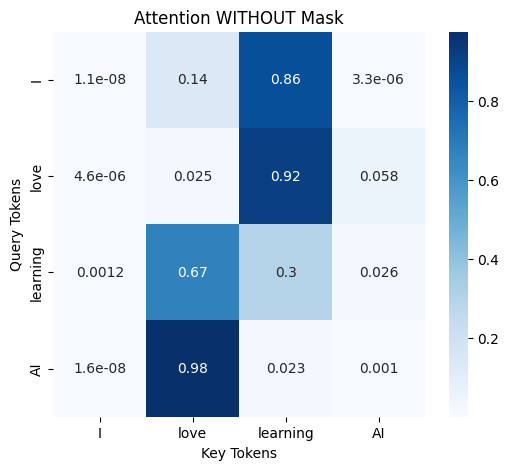

In [3]:
# Visualize attention (When processing this word, which words does it pay attention to)

plt.figure(figsize=(6,5))
sns.heatmap(attention.detach().numpy(),
            xticklabels=tokens,
            yticklabels=tokens,
            cmap="Blues",
            annot=True)

plt.title("Attention WITHOUT Mask")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()

In [4]:
# Add casual mask

# Create causal mask
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
mask = mask.masked_fill(mask == 1, float('-inf'))

# Apply mask
masked_scores = scores + mask

# Softmax again
causal_attention = F.softmax(masked_scores, dim=-1)

print("Attention Matrix (Causal Mask):")
print(causal_attention)

Attention Matrix (Causal Mask):
tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.8563e-04, 9.9981e-01, 0.0000e+00, 0.0000e+00],
        [1.2790e-03, 6.9146e-01, 3.0727e-01, 0.0000e+00],
        [1.5866e-08, 9.7552e-01, 2.3437e-02, 1.0446e-03]])


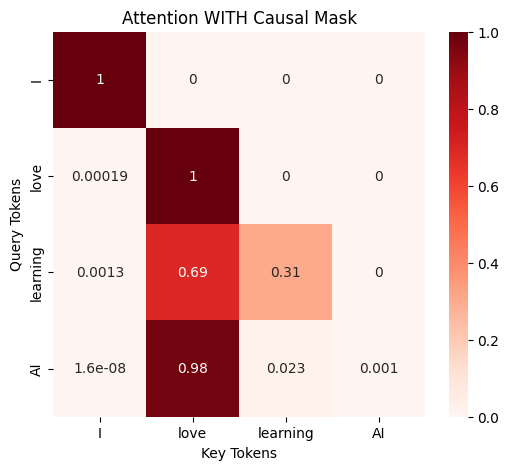

In [5]:
# visualize casual attention

plt.figure(figsize=(6,5))
sns.heatmap(causal_attention.detach().numpy(),
            xticklabels=tokens,
            yticklabels=tokens,
            cmap="Reds",
            annot=True)

plt.title("Attention WITH Causal Mask")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()

In [ ]:
'''Without causal masking, each token can attend to all tokens in the sequence (past, present, and future), so attention is spread across the entire row of the matrix.

With causal masking, each token can attend only to itself and previous tokens, so the attention matrix becomes lower-triangular, blocking attention to future tokens.'''